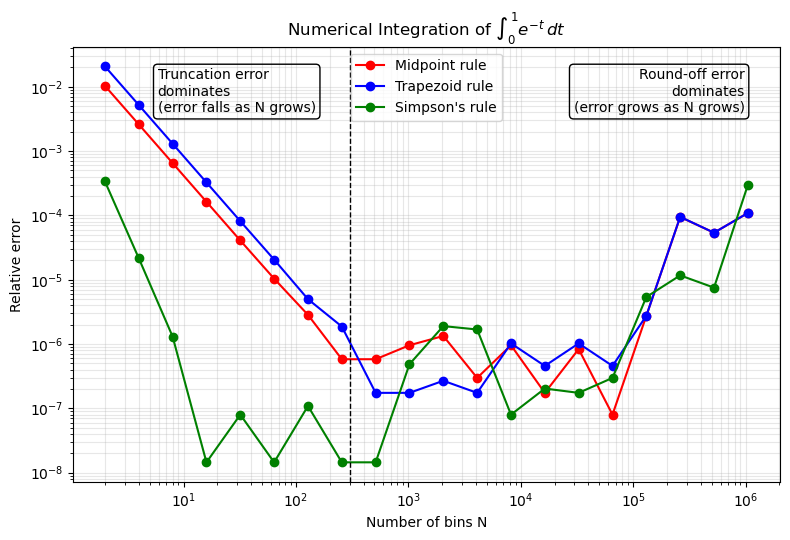

In [19]:
# Single precision numerical differentiation of cos(x) and exp(x)

import numpy as np
import matplotlib.pyplot as plt

#define function in single precision
def f(t):
    return np.float32(np.exp(np.float32(-t)))

#define integration rules
def midpoint_rule(N):
    dt = np.float32(1.0 / N)
    total = np.float32(0.0)
    for i in range(N):
        t = np.float32((i + 0.5) * dt)
        total += f(t)
    return total * dt

def trapezoid_rule(N):
    dt = np.float32(1.0 / N)
    total = np.float32(0.5) * f(np.float32(0.0)) + np.float32(0.5) * f(np.float32(1.0))
    for i in range(1, N):
        t = np.float32(i * dt)
        total += f(t)
    return total * dt

def simpson_rule(N):
    if N % 2 != 0:
        raise ValueError("N must be even")
    dt = np.float32(1.0 / N)
    total = f(np.float32(0.0)) + f(np.float32(1.0))
    for i in range(1, N):
        t = np.float32(i * dt)
        if i % 2 == 1:
            total += np.float32(4.0) * f(t)
        else:
            total += np.float32(2.0) * f(t)
    return total * dt / np.float32(3.0)

#exact integral for relative error calculation
exact = 1 - np.exp(-1)   

#defining relative error
def relative_error(numerical):
    return abs((float(numerical) - exact) / exact)

N_values = 2 ** np.arange(1, 21)   #up to N ~ 1 million, still shows round-off rising

mid_err, trap_err, simp_err = [], [], []
for N in N_values:
    N = int(N)
    mid_err.append(relative_error(midpoint_rule(N)))
    trap_err.append(relative_error(trapezoid_rule(N)))
    simp_err.append(relative_error(simpson_rule(N)))
    
#plotting relative error vs bin size
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.loglog(N_values, mid_err, "o-", color="red", label="Midpoint rule")
ax.loglog(N_values, trap_err, "o-", color="blue", label="Trapezoid rule")
ax.loglog(N_values, simp_err, "o-", color="green", label="Simpson's rule")

#mark the boundary between the two error regimes with a plain vertical line
boundary = 300
ax.axvline(boundary, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Number of bins N")
ax.set_ylabel("Relative error")
ax.set_title(r"Numerical Integration of $\int_0^1 e^{-t}\,dt$")

ax.text(0.12, 0.95, "Truncation error\ndominates\n(error falls as N grows)",
        transform=ax.transAxes, fontsize=10, color="black",
        ha="left", va="top",
        bbox=dict(boxstyle="round", facecolor="none", edgecolor="black"))

ax.text(0.95, 0.95, "Round-off error\ndominates\n(error grows as N grows)",
        transform=ax.transAxes, fontsize=10, color="black",
        ha="right", va="top",
        bbox=dict(boxstyle="round", facecolor="none", edgecolor="black"))

ax.legend(loc="upper center")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig("HWQ2.png", dpi=150)
plt.show()